In [60]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
import math
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [24]:
class ROC_AUC_Callback(keras.callbacks.Callback):
    """Кастомный callback для расчета ROC AUC после каждой эпохи"""
    
    def __init__(self, validation_data, average='macro'):
        super().__init__()
        self.validation_data = validation_data
        self.average = average
        self.val_roc_auc_scores = []
        
    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val = self.validation_data
        y_pred = self.model.predict(X_val, verbose=0, batch_size=512)
        
        # Расчет ROC AUC
        try:
            roc_auc = roc_auc_score(y_val, y_pred, average=self.average)
            logs['val_roc_auc'] = roc_auc
            self.val_roc_auc_scores.append(roc_auc)
        except Exception as e:
            print(f'\nНе удалось рассчитать ROC AUC: {e}')

In [25]:
def create_model(input_dim, output_dim, hidden_layers=[128, 64, 32], dropout_rate=0.3):
    """
    Создание полносвязной модели для многоклассовой классификации с пересекающимися классами
    
    Parameters:
    -----------
    input_dim : int - количество признаков
    output_dim : int - количество классов
    hidden_layers : list - список размеров скрытых слоев
    dropout_rate : float - доля dropout для регуляризации
    
    Returns:
    --------
    model : keras.Model - скомпилированная модель
    """
    
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Добавление скрытых слоев
    for units in hidden_layers:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    
    # Выходной слой с сигмоидой для многоклассовой классификации с пересекающимися классами
    model.add(layers.Dense(output_dim, activation='sigmoid'))
    
    # Компиляция модели
    # Для многоклассовой классификации с пересекающимися классами используем binary_crossentropy
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',  # Подходит для multilabel задачи
        metrics=['accuracy', keras.metrics.AUC(name='auc', multi_label=True)]
    )
    
    return model

In [26]:
def cross_validate_model(X, Y, n_splits=5, epochs=50, batch_size=32, 
                         hidden_layers=[128, 64, 32], dropout_rate=0.3,
                         random_state=42):
    """
    Выполнение кросс-валидации для модели
    
    Parameters:
    -----------
    X : np.array - матрица признаков
    Y : np.array - матрица меток (может содержать несколько единиц в строке)
    n_splits : int - количество фолдов для кросс-валидации
    epochs : int - количество эпох обучения
    batch_size : int - размер батча
    hidden_layers : list - список размеров скрытых слоев
    dropout_rate : float - доля dropout
    random_state : int - seed для воспроизводимости
    
    Returns:
    --------
    results : dict - словарь с результатами кросс-валидации
    """
    
    input_dim = X.shape[1]
    output_dim = Y.shape[1]
    
    # Используем KFold для разделения данных (можно использовать StratifiedKFold для multilabel)
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    fold_histories = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, Y)):
        print(f'\n{"="*50}')
        print(f'Fold {fold + 1}/{n_splits}')
        print(f'='*50)
        
        # Разделение данных
        X_train, X_val = X.iloc[train_idx,:], X.iloc[val_idx,:]
        Y_train, Y_val = Y[train_idx], Y[val_idx]
        
        # Создание модели для текущего фолда
        model = create_model(
            input_dim=input_dim,
            output_dim=output_dim,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate
        )
        
        
        roc_auc_callback = ROC_AUC_Callback(
            validation_data=(X_val, Y_val),
            average='macro'
        )
        
        # Обучение модели
        history = model.fit(
            X_train, Y_train,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[roc_auc_callback],
            verbose=1
        )
        
        fold_histories.append(history)
        
    return fold_histories

In [27]:
def bagging(n_bags, X, Y):
    input_dim = X.shape[1]
    output_dim = Y.shape[1]
    models = []
    for i in range(n_bags):
        print("="*50)
        print(f"Bag {i}")
        print("="*50)
        t0 = time.time()
        X_boot, y_boot = resample(X, Y, replace=True, n_samples=len(X))
        model = create_model(input_dim=input_dim, output_dim=output_dim, hidden_layers=[256,256,256], dropout_rate=0.2)
        model.fit(
            X_boot, y_boot,
            epochs=50,
            batch_size=512,
            verbose=0
        )
        print(f"time_elapsed = {time.time()-t0}")
        models.append(model)
        print()
    return models

# Loading all the data

In [28]:
Y = pd.read_parquet("/kaggle/input/datasets/lolikion228/some-serious-shit/data/train_target.parquet")
Y = Y.iloc[:,1:].to_numpy()

In [29]:
sample_submit = pd.read_parquet("/kaggle/input/datasets/lolikion228/some-serious-shit/data/sample_submit.parquet")

In [30]:
X_main = pd.read_parquet("/kaggle/input/hack-main-feats-25-02-10-19-05/train_main_feats.parquet")
X_extra = pd.read_parquet("/kaggle/input/hack-extra-feats-25-02-16-37-33/train_extra_feats.parquet")

In [31]:
print(X_main.shape, X_extra.shape)

(750000, 410) (750000, 512)


In [32]:
X = pd.concat([X_main,X_extra],axis=1)
del X_main, X_extra

In [33]:
X_test_main = pd.read_parquet("/kaggle/input/hack-main-feats-25-02-10-19-05/test_main_feats.parquet")
X_test_extra = pd.read_parquet("/kaggle/input/hack-extra-feats-25-02-16-37-33/test_extra_feats.parquet")

In [34]:
X_test = pd.concat([X_test_main,X_test_extra],axis=1)
del X_test_main, X_test_extra

# NN

In [35]:
histories = cross_validate_model(
    X, Y,
    n_splits=5,
    epochs=30,
    batch_size=512,
    hidden_layers=[256, 256, 256],
    dropout_rate=0.2
)


Fold 1/5
Epoch 1/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.2926 - auc: 0.5596 - loss: 0.2500 - val_roc_auc: 0.7390
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3688 - auc: 0.6847 - loss: 0.0919 - val_roc_auc: 0.7703
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3760 - auc: 0.7121 - loss: 0.0898 - val_roc_auc: 0.7875
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3810 - auc: 0.7258 - loss: 0.0884 - val_roc_auc: 0.7963
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3828 - auc: 0.7342 - loss: 0.0878 - val_roc_auc: 0.8019
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3862 - auc: 0.7410 - loss: 0.0870 - val_roc_auc: 0.8036
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3878 - auc: 0.7474 - loss: 0.0867 - val_roc_auc: 0.8078
Epoch 8/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3900 - auc: 0.7524 - loss: 0.0859 - val_roc_auc: 0.80

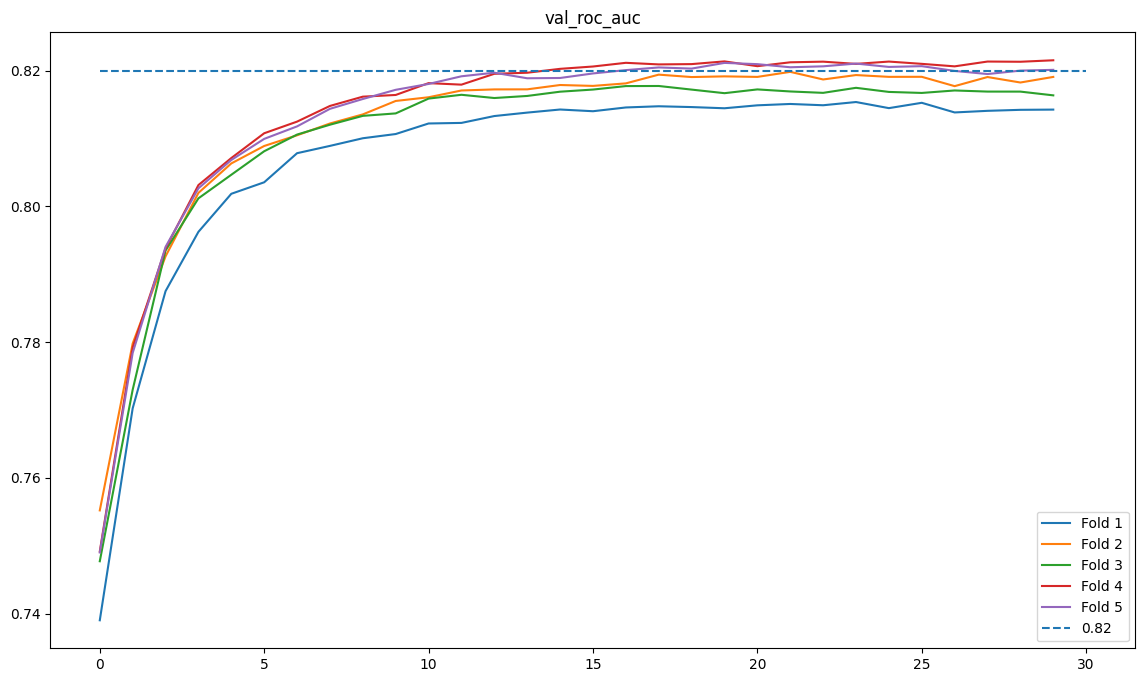

In [57]:
plt.figure(figsize=(14,8))
for i, history in enumerate(histories):
    plt.plot(history.history['val_roc_auc'], label=f'Fold {i+1}')
plt.title('val_roc_auc')
plt.hlines(0.82, 0, 30, linestyles='dashed', label='0.82')
plt.legend(loc='lower right')
plt.show()

# Bagging

In [53]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=116)

In [56]:
print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)

(600000, 922)
(600000, 41)
(150000, 922)
(150000, 41)


In [58]:
n_bags = 40

In [61]:
models = bagging(n_bags, X_train, Y_train)

Bag 0
time_elapsed = 205.0893588066101

Bag 1
time_elapsed = 204.61936855316162

Bag 2
time_elapsed = 210.0636968612671

Bag 3
time_elapsed = 204.85566997528076

Bag 4
time_elapsed = 202.4139015674591

Bag 5
time_elapsed = 204.54904913902283

Bag 6
time_elapsed = 206.1007902622223

Bag 7
time_elapsed = 206.08286380767822

Bag 8
time_elapsed = 204.5314497947693

Bag 9
time_elapsed = 202.97097158432007

Bag 10
time_elapsed = 203.76419758796692

Bag 11
time_elapsed = 214.61036610603333

Bag 12
time_elapsed = 209.26776123046875

Bag 13
time_elapsed = 212.50026273727417

Bag 14
time_elapsed = 212.41810607910156

Bag 15
time_elapsed = 204.8972771167755

Bag 16
time_elapsed = 209.45705342292786

Bag 17
time_elapsed = 212.92984914779663

Bag 18
time_elapsed = 210.43174266815186

Bag 19
time_elapsed = 210.4468412399292

Bag 20
time_elapsed = 209.88521003723145

Bag 21
time_elapsed = 203.30465698242188

Bag 22
time_elapsed = 202.50788760185242

Bag 23
time_elapsed = 201.62099504470825

Bag 24
ti

In [62]:
Y_pred = 0
for i in range(n_bags):
    Y_pred += models[i].predict(X_val, verbose=0, batch_size=512)
Y_pred /= n_bags

In [63]:
roc_auc_score(Y_val, Y_pred, average="macro")

np.float64(0.8260424304467866)

# Creating the submit

In [ ]:
my_submit = sample_submit.copy()

In [ ]:
# не берём логарифм от нуля
Y_pred[np.where(Y_pred==0)] = 1e-10

In [ ]:
my_submit.iloc[:,1:] = np.log(Y_pred)

In [ ]:
my_submit.to_parquet("subbmit.parquet", index=False)